# PM2.5 Prediction from VAE Latent Space (latent6_nodoy)

Can the 6D latent embeddings predict log(PM2.5)?

Compare:
1. **Linear regression** on Z_mu (6 latent dims)
2. **Linear regression** on raw features (16 features) — baseline
3. **Random forest** on Z_mu — can nonlinear decoding of the latent space do better?

All evaluated with random 80/20 train/test split (pooled, not LOSO — this is a quick check of information content, not a proper spatial CV).

In [1]:
import os
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

os.chdir('/home/vcaristo/pm_data/vae/runs/latent6_nodoy')

# Load data
df = pd.read_parquet('/home/vcaristo/pm_data/svgp/full_conus/loso_temp_data.parquet')
emb = np.load('embeddings.npz')
Z_mu = emb['z_mu']  # (1.9M, 6)
assignments = emb['assignments']
feature_cols = list(emb['feature_cols'])

# Target
y = np.log(df['pm25'].values + 1)

# Raw features (same 16 used by VAE, standardized)
time_varying = ['aot', 'wind', 'hgt', 'cld', 'longwave', 'rh', 'tmax', 'smogI', 'smogP']
static = ['lat', 'lon', 'logpd2500g', 'minf_5000', 'sd50k', 'heavy_industrial_ind1', 'housing']
raw_cols = [f for f in time_varying if f in df.columns] + [f for f in static if f in df.columns]
X_raw = df[raw_cols].values

print(f"Z_mu: {Z_mu.shape}, X_raw: {X_raw.shape}, y: {y.shape}")

# Train/test split
idx_train, idx_test = train_test_split(np.arange(len(y)), test_size=0.2, random_state=42)
y_train, y_test = y[idx_train], y[idx_test]

print(f"Train: {len(idx_train):,}, Test: {len(idx_test):,}")

Z_mu: (1883144, 6), X_raw: (1883144, 16), y: (1883144,)
Train: 1,506,515, Test: 376,629


## Linear regression: latent vs raw features

In [2]:
results = {}

# 1. Linear regression on latent embeddings (6 dims)
lr_latent = LinearRegression()
lr_latent.fit(Z_mu[idx_train], y_train)
pred_latent = lr_latent.predict(Z_mu[idx_test])
results['LR (6D latent)'] = {
    'r2': r2_score(y_test, pred_latent),
    'rmse': np.sqrt(mean_squared_error(y_test, pred_latent)),
    'n_features': 6,
}

# 2. Linear regression on raw features (16 dims)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_raw[idx_train])
X_test_s = scaler.transform(X_raw[idx_test])

lr_raw = LinearRegression()
lr_raw.fit(X_train_s, y_train)
pred_raw = lr_raw.predict(X_test_s)
results['LR (16 raw features)'] = {
    'r2': r2_score(y_test, pred_raw),
    'rmse': np.sqrt(mean_squared_error(y_test, pred_raw)),
    'n_features': 16,
}

# 3. Linear regression on latent + component assignment (one-hot)
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(sparse_output=False)
comp_onehot = ohe.fit_transform(assignments.reshape(-1, 1))
X_latent_comp = np.hstack([Z_mu, comp_onehot])

lr_comp = LinearRegression()
lr_comp.fit(X_latent_comp[idx_train], y_train)
pred_comp = lr_comp.predict(X_latent_comp[idx_test])
results['LR (6D latent + component)'] = {
    'r2': r2_score(y_test, pred_comp),
    'rmse': np.sqrt(mean_squared_error(y_test, pred_comp)),
    'n_features': X_latent_comp.shape[1],
}

print(f"{'Model':<30} {'R²':>8} {'RMSE':>8} {'Features':>10}")
print("-" * 60)
for name, r in results.items():
    print(f"{name:<30} {r['r2']:>8.4f} {r['rmse']:>8.4f} {r['n_features']:>10}")

Model                                R²     RMSE   Features
------------------------------------------------------------
LR (6D latent)                   0.2203   0.5999          6
LR (16 raw features)             0.3143   0.5625         16
LR (6D latent + component)       0.2677   0.5814         16


## Random forest on latent space

Can a nonlinear model extract more PM2.5 signal from the latent dims? Using a subsample for speed.

In [3]:
# Subsample for RF (1.9M is too slow for full fit)
np.random.seed(42)
n_sub = 200_000
sub_train = np.random.choice(idx_train, n_sub, replace=False)
sub_test = np.random.choice(idx_test, n_sub // 4, replace=False)

# RF on latent
rf_latent = RandomForestRegressor(n_estimators=100, max_depth=15, n_jobs=-1, random_state=42)
rf_latent.fit(Z_mu[sub_train], y[sub_train])
pred_rf_latent = rf_latent.predict(Z_mu[sub_test])
results['RF (6D latent)'] = {
    'r2': r2_score(y[sub_test], pred_rf_latent),
    'rmse': np.sqrt(mean_squared_error(y[sub_test], pred_rf_latent)),
    'n_features': 6,
}

# RF on raw features
rf_raw = RandomForestRegressor(n_estimators=100, max_depth=15, n_jobs=-1, random_state=42)
X_raw_s = StandardScaler().fit_transform(X_raw)
rf_raw.fit(X_raw_s[sub_train], y[sub_train])
pred_rf_raw = rf_raw.predict(X_raw_s[sub_test])
results['RF (16 raw features)'] = {
    'r2': r2_score(y[sub_test], pred_rf_raw),
    'rmse': np.sqrt(mean_squared_error(y[sub_test], pred_rf_raw)),
    'n_features': 16,
}

print(f"\n{'Model':<30} {'R²':>8} {'RMSE':>8} {'Features':>10}")
print("-" * 60)
for name, r in results.items():
    print(f"{name:<30} {r['r2']:>8.4f} {r['rmse']:>8.4f} {r['n_features']:>10}")
print(f"\n(RF models trained on {n_sub:,} / tested on {len(sub_test):,} subsampled points)")


Model                                R²     RMSE   Features
------------------------------------------------------------
LR (6D latent)                   0.2203   0.5999          6
LR (16 raw features)             0.3143   0.5625         16
LR (6D latent + component)       0.2677   0.5814         16
RF (6D latent)                   0.4672   0.4969          6
RF (16 raw features)             0.5400   0.4617         16

(RF models trained on 200,000 / tested on 50,000 subsampled points)


## Visualize predictions

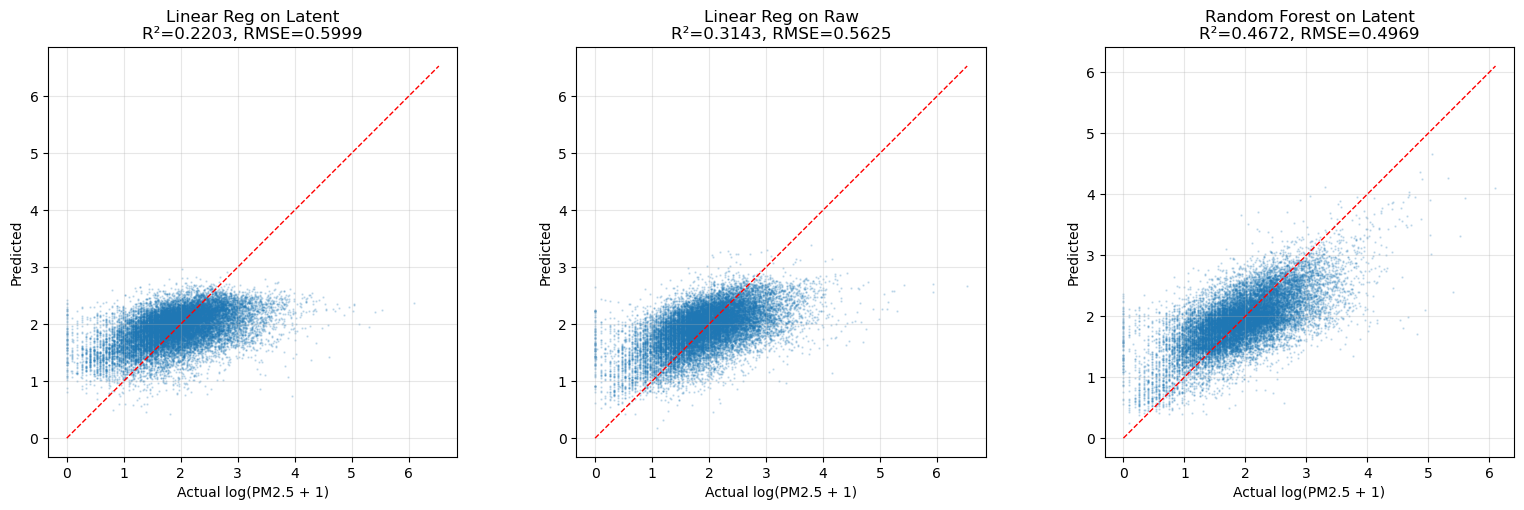

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

comparisons = [
    ('LR (6D latent)', pred_latent, y_test, 'Linear Reg on Latent'),
    ('LR (16 raw features)', pred_raw, y_test, 'Linear Reg on Raw'),
    ('RF (6D latent)', pred_rf_latent, y[sub_test], 'Random Forest on Latent'),
]

for ax, (name, pred, actual, title) in zip(axes, comparisons):
    r2 = results[name]['r2']
    rmse = results[name]['rmse']
    
    # Subsample for plotting
    n_pts = min(20_000, len(pred))
    pidx = np.random.choice(len(pred), n_pts, replace=False)
    
    ax.scatter(actual[pidx], pred[pidx], s=0.5, alpha=0.2, rasterized=True)
    lims = [actual.min(), actual.max()]
    ax.plot(lims, lims, 'r--', linewidth=1)
    ax.set_xlabel('Actual log(PM2.5 + 1)')
    ax.set_ylabel('Predicted')
    ax.set_title(f'{title}\nR²={r2:.4f}, RMSE={rmse:.4f}')
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('plots/pm25_prediction.png', dpi=150, bbox_inches='tight')
plt.show()

## What do the latent dimensions capture?

Correlate each latent dim with the original features and with PM2.5.

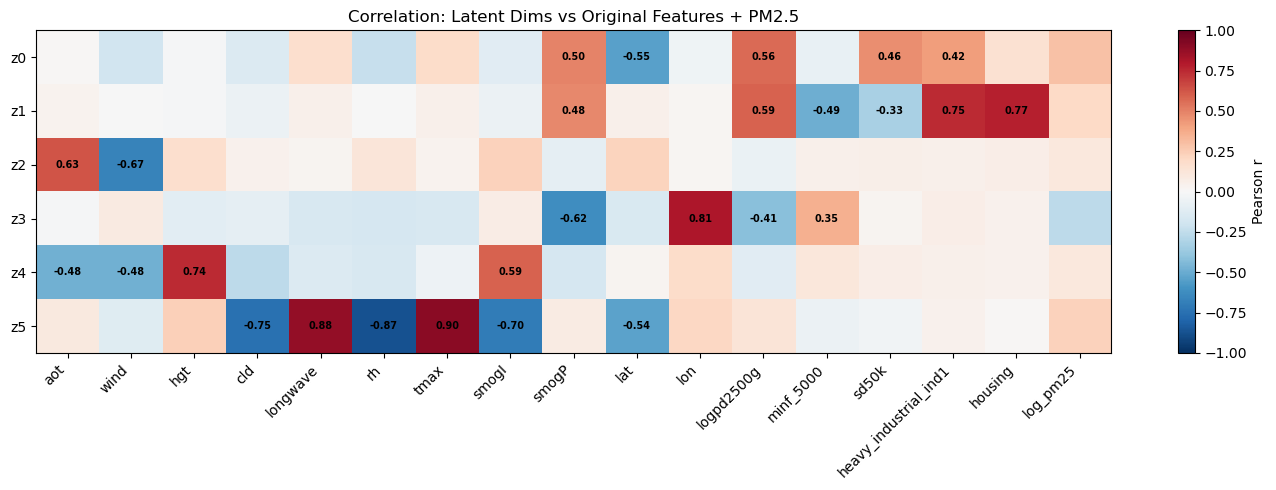

Latent dim correlation with log(PM2.5):
  z0: r = +0.290 (|r| = 0.290)
  z3: r = -0.258 (|r| = 0.258)
  z5: r = +0.228 (|r| = 0.228)
  z1: r = +0.201 (|r| = 0.201)
  z2: r = +0.109 (|r| = 0.109)
  z4: r = +0.102 (|r| = 0.102)


In [5]:
# Correlation of each latent dim with original features and PM2.5
n_corr = 200_000  # subsample for speed
cidx = np.random.choice(len(Z_mu), n_corr, replace=False)

corr_data = np.column_stack([Z_mu[cidx], X_raw[cidx], y[cidx]])
col_names = [f'z{i}' for i in range(6)] + raw_cols + ['log_pm25']
corr_df = pd.DataFrame(corr_data, columns=col_names)
corr_matrix = corr_df.corr()

# Extract latent-vs-features block
latent_cols = [f'z{i}' for i in range(6)]
target_cols = raw_cols + ['log_pm25']
block = corr_matrix.loc[latent_cols, target_cols]

fig, ax = plt.subplots(figsize=(14, 5))
im = ax.imshow(block.values, cmap='RdBu_r', aspect='auto', vmin=-1, vmax=1)
ax.set_yticks(range(len(latent_cols)))
ax.set_yticklabels(latent_cols)
ax.set_xticks(range(len(target_cols)))
ax.set_xticklabels(target_cols, rotation=45, ha='right')
ax.set_title('Correlation: Latent Dims vs Original Features + PM2.5')
plt.colorbar(im, ax=ax, label='Pearson r')

for i in range(block.shape[0]):
    for j in range(block.shape[1]):
        v = block.iloc[i, j]
        if abs(v) > 0.3:
            ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=7, fontweight='bold')

plt.tight_layout()
plt.savefig('plots/latent_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

# Which latent dims correlate most with PM2.5?
pm25_corr = block['log_pm25'].abs().sort_values(ascending=False)
print("Latent dim correlation with log(PM2.5):")
for dim, r in pm25_corr.items():
    print(f"  {dim}: r = {block.loc[dim, 'log_pm25']:+.3f} (|r| = {r:.3f})")

## Per-component random forests

Train a separate RF within each GMM component. Each test point is predicted by the RF for its assigned component.

In [6]:
# Per-component RF on latent space
K = len(np.unique(assignments))
pred_per_comp_latent = np.full(len(sub_test), np.nan)
pred_per_comp_raw = np.full(len(sub_test), np.nan)

comp_results = []

for k in range(K):
    # Train: points in this component within sub_train
    train_mask = assignments[sub_train] == k
    test_mask = assignments[sub_test] == k
    
    n_tr = train_mask.sum()
    n_te = test_mask.sum()
    
    if n_tr < 50 or n_te < 10:
        print(f"  Component {k}: skipped (n_train={n_tr}, n_test={n_te})")
        continue
    
    # RF on latent
    rf_k = RandomForestRegressor(n_estimators=100, max_depth=15, n_jobs=-1, random_state=42)
    rf_k.fit(Z_mu[sub_train[train_mask]], y[sub_train[train_mask]])
    pred_per_comp_latent[test_mask] = rf_k.predict(Z_mu[sub_test[test_mask]])
    
    # RF on raw features
    rf_k_raw = RandomForestRegressor(n_estimators=100, max_depth=15, n_jobs=-1, random_state=42)
    rf_k_raw.fit(X_raw_s[sub_train[train_mask]], y[sub_train[train_mask]])
    pred_per_comp_raw[test_mask] = rf_k_raw.predict(X_raw_s[sub_test[test_mask]])
    
    r2_k_latent = r2_score(y[sub_test[test_mask]], pred_per_comp_latent[test_mask])
    r2_k_raw = r2_score(y[sub_test[test_mask]], pred_per_comp_raw[test_mask])
    
    comp_results.append({
        'component': k, 'n_train': n_tr, 'n_test': n_te,
        'r2_latent': r2_k_latent, 'r2_raw': r2_k_raw,
        'mean_pm25': y[sub_train[train_mask]].mean(),
    })
    print(f"  Component {k}: n_train={n_tr:>6,} n_test={n_te:>5,} | "
          f"R²_latent={r2_k_latent:.4f}  R²_raw={r2_k_raw:.4f}")

# Overall R² from per-component predictions
valid = ~np.isnan(pred_per_comp_latent)
overall_r2_latent = r2_score(y[sub_test[valid]], pred_per_comp_latent[valid])
overall_r2_raw = r2_score(y[sub_test[valid]], pred_per_comp_raw[valid])

results['RF per-comp (6D latent)'] = {
    'r2': overall_r2_latent,
    'rmse': np.sqrt(mean_squared_error(y[sub_test[valid]], pred_per_comp_latent[valid])),
    'n_features': 6,
}
results['RF per-comp (16 raw)'] = {
    'r2': overall_r2_raw,
    'rmse': np.sqrt(mean_squared_error(y[sub_test[valid]], pred_per_comp_raw[valid])),
    'n_features': 16,
}

print(f"\nOverall R² (per-component RF):")
print(f"  Latent 6D:    {overall_r2_latent:.4f}")
print(f"  Raw 16 feat:  {overall_r2_raw:.4f}")
print(f"  (vs single RF latent: {results['RF (6D latent)']['r2']:.4f}, single RF raw: {results['RF (16 raw features)']['r2']:.4f})")

  Component 0: n_train=20,763 n_test=5,278 | R²_latent=0.3996  R²_raw=0.4753


  Component 1: n_train=11,319 n_test=2,856 | R²_latent=0.3149  R²_raw=0.4514


  Component 2: n_train=20,413 n_test=5,255 | R²_latent=0.4939  R²_raw=0.5642


  Component 3: n_train=19,915 n_test=4,985 | R²_latent=0.3277  R²_raw=0.4401


  Component 4: n_train=65,668 n_test=16,373 | R²_latent=0.3466  R²_raw=0.4366


  Component 5: n_train=17,464 n_test=4,268 | R²_latent=0.3240  R²_raw=0.5018


  Component 6: n_train= 3,516 n_test=  855 | R²_latent=0.1986  R²_raw=0.3017


  Component 7: n_train= 7,687 n_test=1,935 | R²_latent=0.3243  R²_raw=0.3939


  Component 8: n_train=22,769 n_test=5,693 | R²_latent=0.3285  R²_raw=0.4448


  Component 9: n_train=10,486 n_test=2,502 | R²_latent=0.2994  R²_raw=0.4009

Overall R² (per-component RF):
  Latent 6D:    0.4738
  Raw 16 feat:  0.5578
  (vs single RF latent: 0.4672, single RF raw: 0.5400)


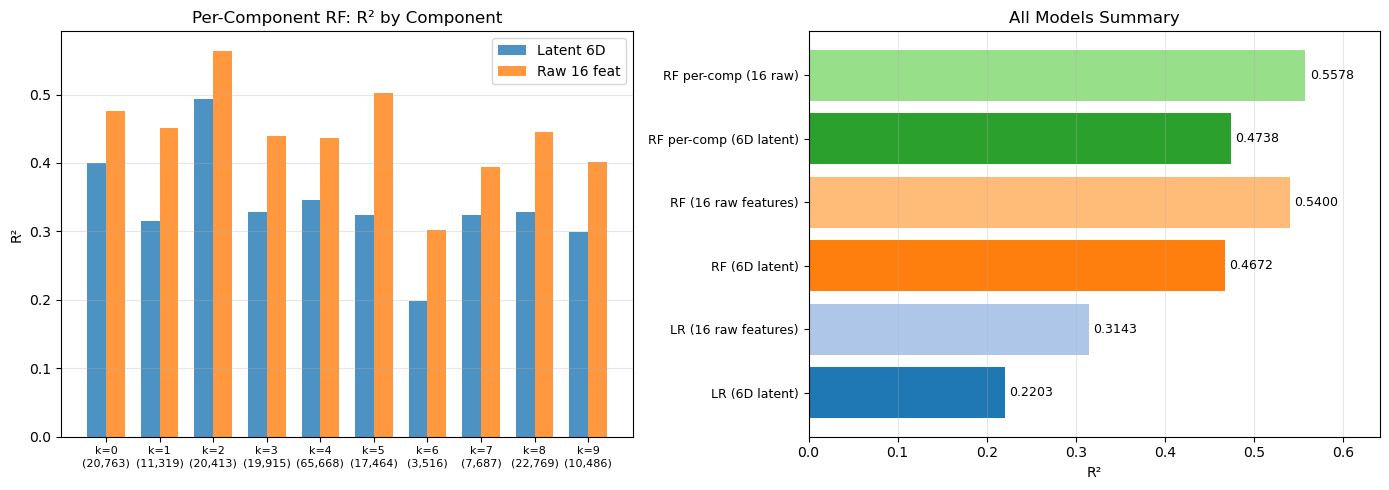

In [7]:
# Per-component R² comparison
comp_df = pd.DataFrame(comp_results)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
x_pos = np.arange(len(comp_df))
width = 0.35
ax.bar(x_pos - width/2, comp_df['r2_latent'], width, label='Latent 6D', alpha=0.8)
ax.bar(x_pos + width/2, comp_df['r2_raw'], width, label='Raw 16 feat', alpha=0.8)
ax.set_xticks(x_pos)
ax.set_xticklabels([f"k={k}\n({n:,})" for k, n in zip(comp_df['component'], comp_df['n_train'])], fontsize=8)
ax.set_ylabel('R²')
ax.set_title('Per-Component RF: R² by Component')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Summary bar chart
ax = axes[1]
model_names = ['LR (6D latent)', 'LR (16 raw features)', 'RF (6D latent)', 
               'RF (16 raw features)', 'RF per-comp (6D latent)', 'RF per-comp (16 raw)']
r2_vals = [results[m]['r2'] for m in model_names]
colors = ['#1f77b4', '#aec7e8', '#ff7f0e', '#ffbb78', '#2ca02c', '#98df8a']
ax.barh(range(len(model_names)), r2_vals, color=colors)
ax.set_yticks(range(len(model_names)))
ax.set_yticklabels(model_names, fontsize=9)
ax.set_xlabel('R²')
ax.set_title('All Models Summary')
for i, v in enumerate(r2_vals):
    ax.text(v + 0.005, i, f'{v:.4f}', va='center', fontsize=9)
ax.set_xlim(0, max(r2_vals) * 1.15)
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('plots/per_component_rf.png', dpi=150, bbox_inches='tight')
plt.show()